In [ ]:
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import itertools
import folium
from folium import plugins

In [ ]:
# ============================================================================
# LOAD DATA FROM PREVIOUS PHASES
# ============================================================================

# Population nodes (21 nodes)
population_nodes = [
    'atrium', 'mosque', 'rcdg', 'kalimudan', 'soccer_field', 'ebl', 'library',
    'carim', 'dorm2', 'csm', 'diwa', 'himati_house', 'usc_house', 'castillo',
    'ate_lings', 'lydia', 'aquatics', 'dhk_training_gym', 'dc_sports_complex',
    'cultural_center', 'som'
]

# AED candidates (12 candidates)
aed_candidates = [
    'atrium', 'rcdg', 'ebl', 'library', 'carim', 'csm',
    'aquatics', 'dhk_training_gym', 'dc_sports_complex',
    'cultural_center', 'som'
]

# Normalized risk weights from Phase 3
risk_weights = {
    'atrium': 0.087873462,
    'mosque': 0.012553352,
    'rcdg': 0.175746924,
    'kalimudan': 0.016319357,
    'soccer_field': 0.025106703,
    'ebl': 0.081596786,
    'library': 0.025106703,
    'carim': 0.050213407,
    'dorm2': 0.003263871,
    'csm': 0.087873462,
    'diwa': 0.012553352,
    'himati_house': 0.012553352,
    'usc_house': 0.012553352,
    'castillo': 0.016319357,
    'ate_lings': 0.012553352,
    'lydia': 0.016319357,
    'aquatics': 0.025106703,
    'dhk_training_gym': 0.175746924,
    'dc_sports_complex': 0.050213407,
    'cultural_center': 0.012553352,
    'som': 0.087873462
}

# Coordinates for all nodes (from Phase 1)
coordinates = {
    'atrium': (7.08568424941463, 125.484813938776),
    'mosque': (7.08610886485087, 125.48709598387),
    'rcdg': (7.08678706925016, 125.485253707882),
    'kalimudan': (7.08492896083443, 125.486917758721),
    'soccer_field': (7.08474820939786, 125.486033068241),
    'ebl': (7.0840452935881, 125.485191200348),
    'library': (7.08486936289015, 125.48368758329),
    'carim': (7.08458879048605, 125.479256671112),
    'dorm2': (7.08420398312648, 125.477651291362),
    'csm': (7.08349353647054, 125.47731412018),
    'diwa': (7.0838146423603, 125.476855732972),
    'himati_house': (7.08449074660404, 125.486483180864),
    'usc_house': (7.08487037880898, 125.486525312261),
    'castillo': (7.0841327355289, 125.485538143993),
    'ate_lings': (7.0841043048891, 125.486143150717),
    'lydia': (7.08434000865248, 125.477727886332),
    'aquatics': (7.08378788430726, 125.47169228828),
    'dhk_training_gym': (7.08669073612343, 125.471794187961),
    'dc_sports_complex': (7.08542168486923, 125.470452590546),
    'cultural_center': (7.08680005523044, 125.481304363936),
    'som': (7.08709807540728, 125.484034039486)
}

# Walking time matrix from actual road measurements (calcmaps)
# Times are in seconds - REAL walking distances, not straight-line estimates
walking_times = {}
walking_time_data = [
    # atrium (row 1)
    ('atrium', 'atrium', 0), ('atrium', 'mosque', 288), ('atrium', 'rcdg', 190),
    ('atrium', 'kalimudan', 267), ('atrium', 'soccer_field', 173), ('atrium', 'ebl', 323),
    ('atrium', 'library', 517), ('atrium', 'carim', 964), ('atrium', 'dorm2', 1171),
    ('atrium', 'csm', 1211), ('atrium', 'diwa', 1297), ('atrium', 'himati_house', 234),
    ('atrium', 'usc_house', 214), ('atrium', 'castillo', 261), ('atrium', 'ate_lings', 279),
    ('atrium', 'lydia', 1134), ('atrium', 'aquatics', 1896), ('atrium', 'dhk_training_gym', 1964),
    ('atrium', 'dc_sports_complex', 2053), ('atrium', 'cultural_center', 566), ('atrium', 'som', 272),

    # mosque (row 2)
    ('mosque', 'atrium', 288), ('mosque', 'mosque', 0), ('mosque', 'rcdg', 118),
    ('mosque', 'kalimudan', 204), ('mosque', 'soccer_field', 237), ('mosque', 'ebl', 436),
    ('mosque', 'library', 631), ('mosque', 'carim', 1080), ('mosque', 'dorm2', 1299),
    ('mosque', 'csm', 1359), ('mosque', 'diwa', 1414), ('mosque', 'himati_house', 221),
    ('mosque', 'usc_house', 189), ('mosque', 'castillo', 385), ('mosque', 'ate_lings', 312),
    ('mosque', 'lydia', 1262), ('mosque', 'aquatics', 2031), ('mosque', 'dhk_training_gym', 2102),
    ('mosque', 'dc_sports_complex', 2203), ('mosque', 'cultural_center', 678), ('mosque', 'som', 371),

    # rcdg (row 3)
    ('rcdg', 'atrium', 235), ('rcdg', 'mosque', 190), ('rcdg', 'rcdg', 0),
    ('rcdg', 'kalimudan', 418), ('rcdg', 'soccer_field', 315), ('rcdg', 'ebl', 481),
    ('rcdg', 'library', 682), ('rcdg', 'carim', 1131), ('rcdg', 'dorm2', 1351),
    ('rcdg', 'csm', 1394), ('rcdg', 'diwa', 1449), ('rcdg', 'himati_house', 409),
    ('rcdg', 'usc_house', 392), ('rcdg', 'castillo', 430), ('rcdg', 'ate_lings', 423),
    ('rcdg', 'lydia', 1313), ('rcdg', 'aquatics', 2080), ('rcdg', 'dhk_training_gym', 2155),
    ('rcdg', 'dc_sports_complex', 2253), ('rcdg', 'cultural_center', 514), ('rcdg', 'som', 204),

    # kalimudan (row 4)
    ('kalimudan', 'atrium', 267), ('kalimudan', 'mosque', 204), ('kalimudan', 'rcdg', 418),
    ('kalimudan', 'kalimudan', 0), ('kalimudan', 'soccer_field', 90), ('kalimudan', 'ebl', 298),
    ('kalimudan', 'library', 492), ('kalimudan', 'carim', 945), ('kalimudan', 'dorm2', 1153),
    ('kalimudan', 'csm', 1213), ('kalimudan', 'diwa', 1273), ('kalimudan', 'himati_house', 97),
    ('kalimudan', 'usc_house', 52), ('kalimudan', 'castillo', 241), ('kalimudan', 'ate_lings', 172),
    ('kalimudan', 'lydia', 1124), ('kalimudan', 'aquatics', 1890), ('kalimudan', 'dhk_training_gym', 1964),
    ('kalimudan', 'dc_sports_complex', 2055), ('kalimudan', 'cultural_center', 903), ('kalimudan', 'som', 509),

    # soccer_field (row 5)
    ('soccer_field', 'atrium', 173), ('soccer_field', 'mosque', 237), ('soccer_field', 'rcdg', 315),
    ('soccer_field', 'kalimudan', 90), ('soccer_field', 'soccer_field', 0), ('soccer_field', 'ebl', 233),
    ('soccer_field', 'library', 427), ('soccer_field', 'carim', 877), ('soccer_field', 'dorm2', 1089),
    ('soccer_field', 'csm', 1147), ('soccer_field', 'diwa', 1211), ('soccer_field', 'himati_house', 76),
    ('soccer_field', 'usc_house', 62), ('soccer_field', 'castillo', 176), ('soccer_field', 'ate_lings', 112),
    ('soccer_field', 'lydia', 1057), ('soccer_field', 'aquatics', 1830), ('soccer_field', 'dhk_training_gym', 1900),
    ('soccer_field', 'dc_sports_complex', 2012), ('soccer_field', 'cultural_center', 678), ('soccer_field', 'som', 375),

    # ebl (row 6)
    ('ebl', 'atrium', 323), ('ebl', 'mosque', 436), ('ebl', 'rcdg', 481),
    ('ebl', 'kalimudan', 298), ('ebl', 'soccer_field', 233), ('ebl', 'ebl', 0),
    ('ebl', 'library', 266), ('ebl', 'carim', 715), ('ebl', 'dorm2', 934),
    ('ebl', 'csm', 980), ('ebl', 'diwa', 1063), ('ebl', 'himati_house', 243),
    ('ebl', 'usc_house', 283), ('ebl', 'castillo', 100), ('ebl', 'ate_lings', 168),
    ('ebl', 'lydia', 897), ('ebl', 'aquatics', 1667), ('ebl', 'dhk_training_gym', 1742),
    ('ebl', 'dc_sports_complex', 1844), ('ebl', 'cultural_center', 963), ('ebl', 'som', 549),

    # library (row 7)
    ('library', 'atrium', 517), ('library', 'mosque', 631), ('library', 'rcdg', 682),
    ('library', 'kalimudan', 492), ('library', 'soccer_field', 427), ('library', 'ebl', 266),
    ('library', 'library', 0), ('library', 'carim', 617), ('library', 'dorm2', 847),
    ('library', 'csm', 881), ('library', 'diwa', 966), ('library', 'himati_house', 422),
    ('library', 'usc_house', 455), ('library', 'castillo', 273), ('library', 'ate_lings', 346),
    ('library', 'lydia', 809), ('library', 'aquatics', 1511), ('library', 'dhk_training_gym', 1662),
    ('library', 'dc_sports_complex', 1766), ('library', 'cultural_center', 869), ('library', 'som', 726),

    # carim (row 8)
    ('carim', 'atrium', 964), ('carim', 'mosque', 1080), ('carim', 'rcdg', 1131),
    ('carim', 'kalimudan', 945), ('carim', 'soccer_field', 877), ('carim', 'ebl', 715),
    ('carim', 'library', 617), ('carim', 'carim', 0), ('carim', 'dorm2', 239),
    ('carim', 'csm', 300), ('carim', 'diwa', 378), ('carim', 'himati_house', 876),
    ('carim', 'usc_house', 913), ('carim', 'castillo', 729), ('carim', 'ate_lings', 800),
    ('carim', 'lydia', 218), ('carim', 'aquatics', 989), ('carim', 'dhk_training_gym', 1056),
    ('carim', 'dc_sports_complex', 1158), ('carim', 'cultural_center', 490), ('carim', 'som', 809),

    # dorm2 (row 9)
    ('dorm2', 'atrium', 1171), ('dorm2', 'mosque', 1299), ('dorm2', 'rcdg', 1351),
    ('dorm2', 'kalimudan', 1153), ('dorm2', 'soccer_field', 1089), ('dorm2', 'ebl', 934),
    ('dorm2', 'library', 847), ('dorm2', 'carim', 239), ('dorm2', 'dorm2', 0),
    ('dorm2', 'csm', 80), ('dorm2', 'diwa', 149), ('dorm2', 'himati_house', 1081),
    ('dorm2', 'usc_house', 1120), ('dorm2', 'castillo', 935), ('dorm2', 'ate_lings', 976),
    ('dorm2', 'lydia', 20), ('dorm2', 'aquatics', 835), ('dorm2', 'dhk_training_gym', 932),
    ('dorm2', 'dc_sports_complex', 1037), ('dorm2', 'cultural_center', 681), ('dorm2', 'som', 985),

    # csm (row 10)
    ('csm', 'atrium', 1211), ('csm', 'mosque', 1359), ('csm', 'rcdg', 1394),
    ('csm', 'kalimudan', 1213), ('csm', 'soccer_field', 1147), ('csm', 'ebl', 980),
    ('csm', 'library', 881), ('csm', 'carim', 300), ('csm', 'dorm2', 80),
    ('csm', 'csm', 0), ('csm', 'diwa', 50), ('csm', 'himati_house', 1143),
    ('csm', 'usc_house', 1183), ('csm', 'castillo', 995), ('csm', 'ate_lings', 1069),
    ('csm', 'lydia', 88), ('csm', 'aquatics', 898), ('csm', 'dhk_training_gym', 1000),
    ('csm', 'dc_sports_complex', 1099), ('csm', 'cultural_center', 752), ('csm', 'som', 1096),

    # diwa (row 11)
    ('diwa', 'atrium', 1297), ('diwa', 'mosque', 1414), ('diwa', 'rcdg', 1449),
    ('diwa', 'kalimudan', 1273), ('diwa', 'soccer_field', 1211), ('diwa', 'ebl', 1063),
    ('diwa', 'library', 966), ('diwa', 'carim', 378), ('diwa', 'dorm2', 149),
    ('diwa', 'csm', 50), ('diwa', 'diwa', 0), ('diwa', 'himati_house', 1230),
    ('diwa', 'usc_house', 1269), ('diwa', 'castillo', 1086), ('diwa', 'ate_lings', 1161),
    ('diwa', 'lydia', 151), ('diwa', 'aquatics', 857), ('diwa', 'dhk_training_gym', 947),
    ('diwa', 'dc_sports_complex', 1037), ('diwa', 'cultural_center', 836), ('diwa', 'som', 1199),

    # himati_house (row 12)
    ('himati_house', 'atrium', 234), ('himati_house', 'mosque', 221), ('himati_house', 'rcdg', 409),
    ('himati_house', 'kalimudan', 97), ('himati_house', 'soccer_field', 76), ('himati_house', 'ebl', 243),
    ('himati_house', 'library', 422), ('himati_house', 'carim', 876), ('himati_house', 'dorm2', 1081),
    ('himati_house', 'csm', 1143), ('himati_house', 'diwa', 1230), ('himati_house', 'himati_house', 0),
    ('himati_house', 'usc_house', 55), ('himati_house', 'castillo', 167), ('himati_house', 'ate_lings', 98),
    ('himati_house', 'lydia', 1046), ('himati_house', 'aquatics', 1813), ('himati_house', 'dhk_training_gym', 1896),
    ('himati_house', 'dc_sports_complex', 2000), ('himati_house', 'cultural_center', 841), ('himati_house', 'som', 540),

    # usc_house (row 13)
    ('usc_house', 'atrium', 214), ('usc_house', 'mosque', 189), ('usc_house', 'rcdg', 392),
    ('usc_house', 'kalimudan', 52), ('usc_house', 'soccer_field', 62), ('usc_house', 'ebl', 283),
    ('usc_house', 'library', 455), ('usc_house', 'carim', 913), ('usc_house', 'dorm2', 1120),
    ('usc_house', 'csm', 1183), ('usc_house', 'diwa', 1269), ('usc_house', 'himati_house', 55),
    ('usc_house', 'usc_house', 0), ('usc_house', 'castillo', 206), ('usc_house', 'ate_lings', 138),
    ('usc_house', 'lydia', 1088), ('usc_house', 'aquatics', 1866), ('usc_house', 'dhk_training_gym', 1950),
    ('usc_house', 'dc_sports_complex', 2045), ('usc_house', 'cultural_center', 791), ('usc_house', 'som', 492),

    # castillo (row 14)
    ('castillo', 'atrium', 261), ('castillo', 'mosque', 385), ('castillo', 'rcdg', 430),
    ('castillo', 'kalimudan', 241), ('castillo', 'soccer_field', 176), ('castillo', 'ebl', 100),
    ('castillo', 'library', 273), ('castillo', 'carim', 729), ('castillo', 'dorm2', 935),
    ('castillo', 'csm', 995), ('castillo', 'diwa', 1086), ('castillo', 'himati_house', 167),
    ('castillo', 'usc_house', 206), ('castillo', 'castillo', 0), ('castillo', 'ate_lings', 78),
    ('castillo', 'lydia', 902), ('castillo', 'aquatics', 1663), ('castillo', 'dhk_training_gym', 1747),
    ('castillo', 'dc_sports_complex', 1841), ('castillo', 'cultural_center', 974), ('castillo', 'som', 1311),

    # ate_lings (row 15)
    ('ate_lings', 'atrium', 279), ('ate_lings', 'mosque', 312), ('ate_lings', 'rcdg', 423),
    ('ate_lings', 'kalimudan', 172), ('ate_lings', 'soccer_field', 112), ('ate_lings', 'ebl', 168),
    ('ate_lings', 'library', 346), ('ate_lings', 'carim', 800), ('ate_lings', 'dorm2', 976),
    ('ate_lings', 'csm', 1069), ('ate_lings', 'diwa', 1161), ('ate_lings', 'himati_house', 98),
    ('ate_lings', 'usc_house', 138), ('ate_lings', 'castillo', 78), ('ate_lings', 'ate_lings', 0),
    ('ate_lings', 'lydia', 970), ('ate_lings', 'aquatics', 1743), ('ate_lings', 'dhk_training_gym', 1826),
    ('ate_lings', 'dc_sports_complex', 1929), ('ate_lings', 'cultural_center', 786), ('ate_lings', 'som', 483),

    # lydia (row 16)
    ('lydia', 'atrium', 1134), ('lydia', 'mosque', 1262), ('lydia', 'rcdg', 1313),
    ('lydia', 'kalimudan', 1124), ('lydia', 'soccer_field', 1057), ('lydia', 'ebl', 897),
    ('lydia', 'library', 809), ('lydia', 'carim', 218), ('lydia', 'dorm2', 20),
    ('lydia', 'csm', 88), ('lydia', 'diwa', 151), ('lydia', 'himati_house', 1046),
    ('lydia', 'usc_house', 1088), ('lydia', 'castillo', 902), ('lydia', 'ate_lings', 970),
    ('lydia', 'lydia', 0), ('lydia', 'aquatics', 809), ('lydia', 'dhk_training_gym', 892),
    ('lydia', 'dc_sports_complex', 993), ('lydia', 'cultural_center', 661), ('lydia', 'som', 1010),

    # aquatics (row 17)
    ('aquatics', 'atrium', 1896), ('aquatics', 'mosque', 2031), ('aquatics', 'rcdg', 2080),
    ('aquatics', 'kalimudan', 1890), ('aquatics', 'soccer_field', 1830), ('aquatics', 'ebl', 1667),
    ('aquatics', 'library', 1511), ('aquatics', 'carim', 989), ('aquatics', 'dorm2', 835),
    ('aquatics', 'csm', 898), ('aquatics', 'diwa', 857), ('aquatics', 'himati_house', 1813),
    ('aquatics', 'usc_house', 1866), ('aquatics', 'castillo', 1663), ('aquatics', 'ate_lings', 1743),
    ('aquatics', 'lydia', 809), ('aquatics', 'aquatics', 0), ('aquatics', 'dhk_training_gym', 444),
    ('aquatics', 'dc_sports_complex', 521), ('aquatics', 'cultural_center', 1424), ('aquatics', 'som', 1781),

    # dhk_training_gym (row 18)
    ('dhk_training_gym', 'atrium', 1964), ('dhk_training_gym', 'mosque', 2102), ('dhk_training_gym', 'rcdg', 2155),
    ('dhk_training_gym', 'kalimudan', 1964), ('dhk_training_gym', 'soccer_field', 1900), ('dhk_training_gym', 'ebl', 1742),
    ('dhk_training_gym', 'library', 1662), ('dhk_training_gym', 'carim', 1056), ('dhk_training_gym', 'dorm2', 932),
    ('dhk_training_gym', 'csm', 1000), ('dhk_training_gym', 'diwa', 947), ('dhk_training_gym', 'himati_house', 1896),
    ('dhk_training_gym', 'usc_house', 1950), ('dhk_training_gym', 'castillo', 1747), ('dhk_training_gym', 'ate_lings', 1826),
    ('dhk_training_gym', 'lydia', 892), ('dhk_training_gym', 'aquatics', 444), ('dhk_training_gym', 'dhk_training_gym', 0),
    ('dhk_training_gym', 'dc_sports_complex', 100), ('dhk_training_gym', 'cultural_center', 1485), ('dhk_training_gym', 'som', 1814),

    # dc_sports_complex (row 19)
    ('dc_sports_complex', 'atrium', 2053), ('dc_sports_complex', 'mosque', 2203), ('dc_sports_complex', 'rcdg', 2253),
    ('dc_sports_complex', 'kalimudan', 2055), ('dc_sports_complex', 'soccer_field', 2012), ('dc_sports_complex', 'ebl', 1844),
    ('dc_sports_complex', 'library', 1766), ('dc_sports_complex', 'carim', 1158), ('dc_sports_complex', 'dorm2', 1037),
    ('dc_sports_complex', 'csm', 1099), ('dc_sports_complex', 'diwa', 1037), ('dc_sports_complex', 'himati_house', 2000),
    ('dc_sports_complex', 'usc_house', 2045), ('dc_sports_complex', 'castillo', 1841), ('dc_sports_complex', 'ate_lings', 1929),
    ('dc_sports_complex', 'lydia', 993), ('dc_sports_complex', 'aquatics', 521), ('dc_sports_complex', 'dhk_training_gym', 100),
    ('dc_sports_complex', 'dc_sports_complex', 0), ('dc_sports_complex', 'cultural_center', 1585), ('dc_sports_complex', 'som', 1913),

    # cultural_center (row 20)
    ('cultural_center', 'atrium', 566), ('cultural_center', 'mosque', 678), ('cultural_center', 'rcdg', 514),
    ('cultural_center', 'kalimudan', 903), ('cultural_center', 'soccer_field', 678), ('cultural_center', 'ebl', 963),
    ('cultural_center', 'library', 869), ('cultural_center', 'carim', 490), ('cultural_center', 'dorm2', 681),
    ('cultural_center', 'csm', 752), ('cultural_center', 'diwa', 836), ('cultural_center', 'himati_house', 841),
    ('cultural_center', 'usc_house', 791), ('cultural_center', 'castillo', 974), ('cultural_center', 'ate_lings', 786),
    ('cultural_center', 'lydia', 661), ('cultural_center', 'aquatics', 1424), ('cultural_center', 'dhk_training_gym', 1485),
    ('cultural_center', 'dc_sports_complex', 1585), ('cultural_center', 'cultural_center', 0), ('cultural_center', 'som', 400),

    # som (row 21)
    ('som', 'atrium', 272), ('som', 'mosque', 371), ('som', 'rcdg', 204),
    ('som', 'kalimudan', 509), ('som', 'soccer_field', 375), ('som', 'ebl', 549),
    ('som', 'library', 726), ('som', 'carim', 809), ('som', 'dorm2', 985),
    ('som', 'csm', 1096), ('som', 'diwa', 1199), ('som', 'himati_house', 540),
    ('som', 'usc_house', 492), ('som', 'castillo', 1311), ('som', 'ate_lings', 483),
    ('som', 'lydia', 1010), ('som', 'aquatics', 1781), ('som', 'dhk_training_gym', 1814),
    ('som', 'dc_sports_complex', 1913), ('som', 'cultural_center', 400), ('som', 'som', 0),
]

THRESHOLD = 300  # 5 minutes in seconds


In [ ]:
# ============================================================================
# PHASE 4: OPTIMIZATION USING BRUTE FORCE
# ============================================================================

def evaluate_aed_set(selected_aeds, population_nodes, risk_weights, walking_times, threshold=300):
    """
    Calculate total risk-weighted coverage for a given set of AEDs
    """
    total_risk = 0
    for node in population_nodes:
        # Check if any AED covers this node
        is_covered = any(walking_times.get((aed, node), 9999) <= threshold for aed in selected_aeds)
        if is_covered:
            total_risk += risk_weights[node]
    return total_risk

def optimize_aed_bruteforce(budget, aed_candidates, population_nodes, risk_weights, walking_times, threshold=300):
    """
    Brute-force search for best AED combination
    For budget=7: 12 choose 7 = 792 combinations (very fast)
    """
    best_combination = None
    best_risk = 0

    # Generate all combinations
    total_combinations = 0
    for combo in itertools.combinations(aed_candidates, budget):
        total_combinations += 1
        risk_covered = evaluate_aed_set(combo, population_nodes, risk_weights, walking_times, threshold)

        if risk_covered > best_risk:
            best_risk = risk_covered
            best_combination = combo

    return list(best_combination), best_risk, best_risk * 100

print("=" * 80)
print("PHASE 4: AED PLACEMENT OPTIMIZATION (Brute-Force)")
print("=" * 80)

# Fill dictionary
for aed, node, time in walking_time_data:
    walking_times[(aed, node)] = time

# Run optimization for each budget
budgets = [2, 4, 6]
results = {}

for budget in budgets:
    print(f"\n🔍 Searching {budget} AED combination(s) from {len(aed_candidates)} candidates...")
    selected, risk_covered, pct = optimize_aed_bruteforce(
        budget, aed_candidates, population_nodes, risk_weights, walking_times, 300
    )
    results[budget] = {
        'selected_aeds': selected,
        'risk_covered': risk_covered,
        'coverage_pct': pct
    }

    print(f"\n✅ Budget: {budget} AED(s)")
    print(f"   Selected: {', '.join(selected)}")
    print(f"   Risk-weighted coverage: {risk_covered:.3f} / 1.000 ({pct:.1f}%)")

    # Show detailed coverage
    uncovered_high = []
    covered_details = []
    for node in population_nodes:
        covered = any(walking_times.get((aed, node), 9999) <= 300 for aed in selected)
        if covered:
            covered_details.append(node)
        elif risk_weights[node] > 0.05:
            uncovered_high.append(f"{node}({risk_weights[node]*100:.1f}%)")

    if uncovered_high:
        print(f"   ⚠️ Uncovered high-risk nodes (>5%): {', '.join(uncovered_high)}")
    else:
        print(f"   ✅ All high-risk nodes (>5%) covered!")

    print(f"   📊 Total nodes covered: {len(covered_details)}/{len(population_nodes)}")

# Summary table
print("\n" + "=" * 80)
print("PHASE 4 SUMMARY: Optimal AED Placements")
print("=" * 80)

summary_data = []
for budget in budgets:
    summary_data.append({
        'Budget': budget,
        'Selected AEDs': ', '.join(results[budget]['selected_aeds']),
        'Coverage (%)': f"{results[budget]['coverage_pct']:.1f}%",
        'Risk Covered': f"{results[budget]['risk_covered']:.3f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

PHASE 4: AED PLACEMENT OPTIMIZATION (Brute-Force)

🔍 Searching 2 AED combination(s) from 11 candidates...

✅ Budget: 2 AED(s)
   Selected: atrium, dhk_training_gym
   Risk-weighted coverage: 0.685 / 1.000 (68.5%)
   ⚠️ Uncovered high-risk nodes (>5%): ebl(8.2%), carim(5.0%), csm(8.8%)
   📊 Total nodes covered: 12/21

🔍 Searching 4 AED combination(s) from 11 candidates...

✅ Budget: 4 AED(s)
   Selected: atrium, ebl, csm, dhk_training_gym
   Risk-weighted coverage: 0.962 / 1.000 (96.2%)
   ✅ All high-risk nodes (>5%) covered!
   📊 Total nodes covered: 19/21

🔍 Searching 6 AED combination(s) from 11 candidates...

✅ Budget: 6 AED(s)
   Selected: atrium, ebl, csm, aquatics, dhk_training_gym, cultural_center
   Risk-weighted coverage: 1.000 / 1.000 (100.0%)
   ✅ All high-risk nodes (>5%) covered!
   📊 Total nodes covered: 21/21

PHASE 4 SUMMARY: Optimal AED Placements
 Budget                                                 Selected AEDs Coverage (%) Risk Covered
      2                    

In [ ]:
# ============================================================================
# PHASE 5: MONTE CARLO SIMULATION
# ============================================================================

def monte_carlo_simulation(selected_aeds, risk_weights, population_nodes, walking_times,
                          threshold=300, n_days=10000, events_per_day=2):
    """
    Simulate random cardiac events weighted by risk scores
    """
    # Precompute which nodes are covered
    node_coverage = {}
    for node in population_nodes:
        node_coverage[node] = any(walking_times.get((aed, node), 9999) <= threshold
                                  for aed in selected_aeds)

    # Prepare for weighted random selection
    nodes_list = list(risk_weights.keys())
    weights_list = [risk_weights[node] for node in nodes_list]

    # Normalize weights to ensure they sum to 1 (fix rounding errors)
    total = sum(weights_list)
    weights_list = [w / total for w in weights_list]

    total_events = n_days * events_per_day
    covered_events = 0

    np.random.seed(42)  # For reproducibility

    # Generate all events at once
    all_events = np.random.choice(nodes_list, size=total_events, p=weights_list)

    # Count covered events
    for event_location in all_events:
        if node_coverage[event_location]:
            covered_events += 1

    coverage_pct = (covered_events / total_events) * 100
    return coverage_pct

print("\n" + "=" * 80)
print("PHASE 5: MONTE CARLO SIMULATION (10,000 days, 2 events/day)")
print("=" * 80)

simulation_results = {}
for budget in budgets:
    selected = results[budget]['selected_aeds']
    sim_coverage = monte_carlo_simulation(
        selected, risk_weights, population_nodes, walking_times, THRESHOLD
    )
    simulation_results[budget] = sim_coverage

    print(f"\nBudget: {budget} AED(s)")
    print(f"Monte Carlo coverage: {sim_coverage:.1f}%")
    print(f"Optimization predicted: {results[budget]['coverage_pct']:.1f}%")
    print(f"Difference: {sim_coverage - results[budget]['coverage_pct']:.1f}%")


PHASE 5: MONTE CARLO SIMULATION (10,000 days, 2 events/day)

Budget: 2 AED(s)
Monte Carlo coverage: 68.3%
Optimization predicted: 68.5%
Difference: -0.3%

Budget: 4 AED(s)
Monte Carlo coverage: 96.3%
Optimization predicted: 96.2%
Difference: 0.1%

Budget: 6 AED(s)
Monte Carlo coverage: 100.0%
Optimization predicted: 100.0%
Difference: 0.0%


In [ ]:
# ============================================================================
# PHASE 6: VISUALIZATION
# ============================================================================

# Map center (average of all nodes)
center_lat = 7.085
center_lon = 125.48

# Create map
campus_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=16,
    tiles='OpenStreetMap'
)

# Add satellite view option
folium.TileLayer(
    'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google Satellite',
    name='Satellite'
).add_to(campus_map)

# Define colors for AEDs
aed_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# Get optimal AEDs (using your results from Phase 4)
two_aeds = results[2]['selected_aeds']
four_aeds = results[4]['selected_aeds']
six_aeds = results[6]['selected_aeds']

# Add coverage radius circles (420m = 5 min walk at 1.4 m/s)
COVERAGE_RADIUS = 420

for i, aed in enumerate(selected_aeds):
    lat, lon = coordinates[aed]
    color = aed_colors[i % len(aed_colors)]

    # Add radius circle
    folium.Circle(
        location=[lat, lon],
        radius=COVERAGE_RADIUS,
        popup=f"{aed}<br>5-min walk radius ({COVERAGE_RADIUS}m)",
        color=color,
        fill=True,
        fill_opacity=0.15,
        weight=2,
        opacity=0.8
    ).add_to(campus_map)

    # Add AED marker
    folium.Marker(
        location=[lat, lon],
        popup=f"<b>AED Location</b><br>{aed}",
        icon=folium.Icon(color='red', icon='medkit', prefix='fa'),
        tooltip=f"AED: {aed}"
    ).add_to(campus_map)

# Add population nodes
for node in population_nodes:
    lat, lon = coordinates[node]
    risk = risk_weights[node] * 100

    # Check coverage
    is_covered = any(walking_times.get((aed, node), 9999) <= 300 for aed in selected_aeds)

    # Color based on coverage + risk
    if is_covered:
        color = '#2ecc71'  # Green - covered
        icon = 'ok-sign'
    else:
        color = '#e74c3c'  # Red - uncovered
        icon = 'warning-sign'

    # Size based on risk (larger = higher risk)
    radius = 6 + (risk / 15) * 10

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        popup=f"""
        <b>{node.upper()}</b><br>
        Risk: {risk:.2f}%<br>
        Covered: {'✅ YES' if is_covered else '❌ NO'}<br>
        Min walk time: {min([walking_times.get((aed, node), 9999) for aed in selected_aeds])} sec
        """,
        color=color,
        fill=True,
        fill_opacity=0.7,
        weight=2,
        tooltip=f"{node} - {risk:.1f}% risk"
    ).add_to(campus_map)

# Add legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 8px;
            border: 2px solid #ccc; font-size: 13px; line-height: 1.8;
            box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
    <b>📍 LEGEND</b><br>
    <span style="color:#2ecc71">●</span> Covered node<br>
    <span style="color:#e74c3c">●</span> Uncovered node<br>
    <span style="color:red">🔴</span> AED location<br>
    <span style="color:gray">◯</span> 5-min walk radius (420m)<br>
    <i>Circle size = Risk level</i>
</div>
"""
campus_map.get_root().html.add_child(folium.Element(legend_html))

# Add layer control
folium.LayerControl().add_to(campus_map)

campus_map

In [ ]:
for i, aed in enumerate(four_aeds):
    lat, lon = coordinates[aed]
    color = aed_colors[i % len(aed_colors)]

    # Add radius circle
    folium.Circle(
        location=[lat, lon],
        radius=COVERAGE_RADIUS,
        popup=f"{aed}<br>5-min walk radius ({COVERAGE_RADIUS}m)",
        color=color,
        fill=True,
        fill_opacity=0.15,
        weight=2,
        opacity=0.8
    ).add_to(campus_map)

    # Add AED marker
    folium.Marker(
        location=[lat, lon],
        popup=f"<b>AED Location</b><br>{aed}",
        icon=folium.Icon(color='red', icon='medkit', prefix='fa'),
        tooltip=f"AED: {aed}"
    ).add_to(campus_map)

# Add population nodes
for node in population_nodes:
    lat, lon = coordinates[node]
    risk = risk_weights[node] * 100

    # Check coverage
    is_covered = any(walking_times.get((aed, node), 9999) <= 300 for aed in selected_aeds)

    # Color based on coverage + risk
    if is_covered:
        color = '#2ecc71'  # Green - covered
        icon = 'ok-sign'
    else:
        color = '#e74c3c'  # Red - uncovered
        icon = 'warning-sign'

    # Size based on risk (larger = higher risk)
    radius = 6 + (risk / 15) * 10

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        popup=f"""
        <b>{node.upper()}</b><br>
        Risk: {risk:.2f}%<br>
        Covered: {'✅ YES' if is_covered else '❌ NO'}<br>
        Min walk time: {min([walking_times.get((aed, node), 9999) for aed in selected_aeds])} sec
        """,
        color=color,
        fill=True,
        fill_opacity=0.7,
        weight=2,
        tooltip=f"{node} - {risk:.1f}% risk"
    ).add_to(campus_map)

# Add legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 8px;
            border: 2px solid #ccc; font-size: 13px; line-height: 1.8;
            box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
    <b>📍 LEGEND</b><br>
    <span style="color:#2ecc71">●</span> Covered node<br>
    <span style="color:#e74c3c">●</span> Uncovered node<br>
    <span style="color:red">🔴</span> AED location<br>
    <span style="color:gray">◯</span> 5-min walk radius (420m)<br>
    <i>Circle size = Risk level</i>
</div>
"""
campus_map.get_root().html.add_child(folium.Element(legend_html))

# Add layer control
folium.LayerControl().add_to(campus_map)

campus_map

In [ ]:
for i, aed in enumerate(six_aeds):
    lat, lon = coordinates[aed]
    color = aed_colors[i % len(aed_colors)]

    # Add radius circle
    folium.Circle(
        location=[lat, lon],
        radius=COVERAGE_RADIUS,
        popup=f"{aed}<br>5-min walk radius ({COVERAGE_RADIUS}m)",
        color=color,
        fill=True,
        fill_opacity=0.15,
        weight=2,
        opacity=0.8
    ).add_to(campus_map)

    # Add AED marker
    folium.Marker(
        location=[lat, lon],
        popup=f"<b>AED Location</b><br>{aed}",
        icon=folium.Icon(color='red', icon='medkit', prefix='fa'),
        tooltip=f"AED: {aed}"
    ).add_to(campus_map)

# Add population nodes
for node in population_nodes:
    lat, lon = coordinates[node]
    risk = risk_weights[node] * 100

    # Check coverage
    is_covered = any(walking_times.get((aed, node), 9999) <= 300 for aed in selected_aeds)

    # Color based on coverage + risk
    if is_covered:
        color = '#2ecc71'  # Green - covered
        icon = 'ok-sign'
    else:
        color = '#e74c3c'  # Red - uncovered
        icon = 'warning-sign'

    # Size based on risk (larger = higher risk)
    radius = 6 + (risk / 15) * 10

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        popup=f"""
        <b>{node.upper()}</b><br>
        Risk: {risk:.2f}%<br>
        Covered: {'✅ YES' if is_covered else '❌ NO'}<br>
        Min walk time: {min([walking_times.get((aed, node), 9999) for aed in selected_aeds])} sec
        """,
        color=color,
        fill=True,
        fill_opacity=0.7,
        weight=2,
        tooltip=f"{node} - {risk:.1f}% risk"
    ).add_to(campus_map)

# Add legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 8px;
            border: 2px solid #ccc; font-size: 13px; line-height: 1.8;
            box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
    <b>📍 LEGEND</b><br>
    <span style="color:#2ecc71">●</span> Covered node<br>
    <span style="color:#e74c3c">●</span> Uncovered node<br>
    <span style="color:red">🔴</span> AED location<br>
    <span style="color:gray">◯</span> 5-min walk radius (420m)<br>
    <i>Circle size = Risk level</i>
</div>
"""
campus_map.get_root().html.add_child(folium.Element(legend_html))

# Add layer control
folium.LayerControl().add_to(campus_map)

campus_map

✓ Saved: phase6_coverage_vs_budget.png


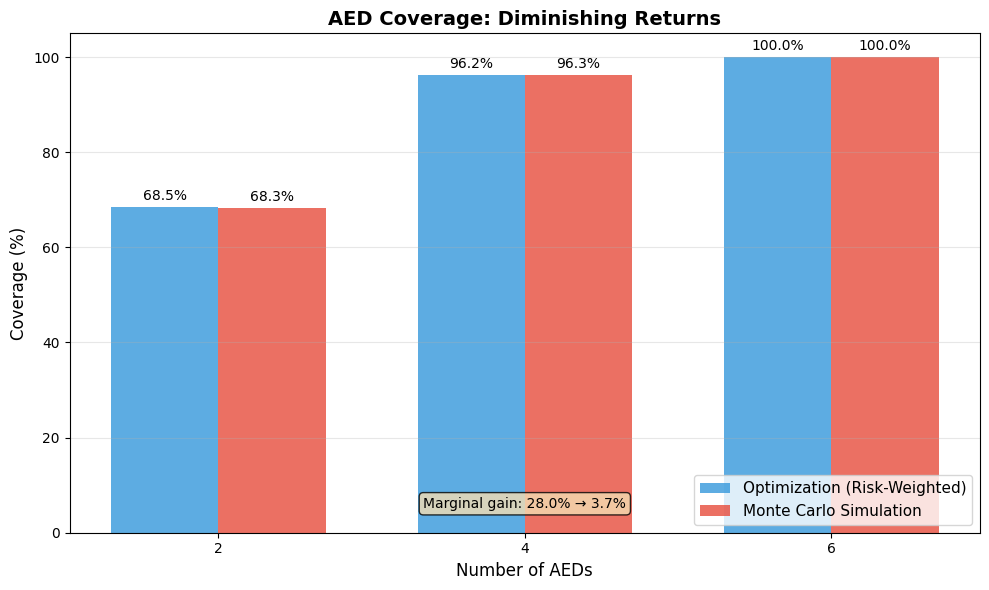

In [ ]:
# -------------------------------------------------------------------------
# VISUAL 2: Coverage vs. Budget Graph
# -------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 6))

budget_labels = [str(b) for b in budgets]
opt_coverage = [results[b]['coverage_pct'] for b in budgets]
sim_coverage = [simulation_results[b] for b in budgets]

x = np.arange(len(budgets))
width = 0.35

bars1 = ax2.bar(x - width/2, opt_coverage, width, label='Optimization (Risk-Weighted)',
                color='#3498db', alpha=0.8)
bars2 = ax2.bar(x + width/2, sim_coverage, width, label='Monte Carlo Simulation',
                color='#e74c3c', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

ax2.set_xlabel('Number of AEDs', fontsize=12)
ax2.set_ylabel('Coverage (%)', fontsize=12)
ax2.set_title('AED Coverage: Diminishing Returns', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(budget_labels)
ax2.set_ylim(0, 105)
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# Add diminishing returns annotation
returns = [(simulation_results[budgets[i]] - simulation_results[budgets[i-1]])
           for i in range(1, len(budgets))]
if returns:
    ax2.annotate(f'Marginal gain: {returns[0]:.1f}% → {returns[1]:.1f}%',
                xy=(0.5, 0.05), xycoords='axes fraction', ha='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('phase6_coverage_vs_budget.png', dpi=150, bbox_inches='tight')
print("✓ Saved: phase6_coverage_vs_budget.png")

✓ Saved: phase6_risk_heatmap.png


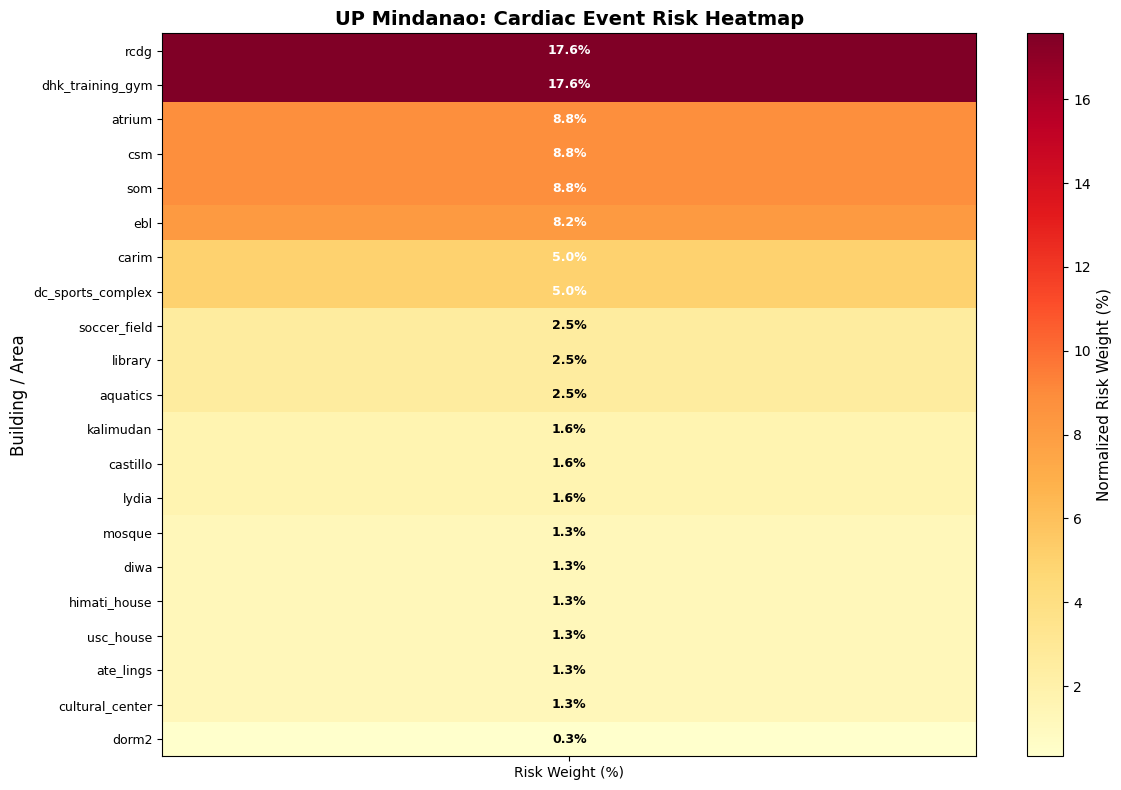

In [ ]:
# -------------------------------------------------------------------------
# VISUAL 3: Risk Heatmap
# -------------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(12, 8))

# Create risk matrix for heatmap
risk_matrix = []
node_labels = []
risk_sorted = sorted(risk_weights.items(), key=lambda x: x[1], reverse=True)

for i, (node, risk) in enumerate(risk_sorted):
    risk_matrix.append([risk * 100])  # Convert to percentage
    node_labels.append(node)

# Create heatmap
im = ax3.imshow(risk_matrix, cmap='YlOrRd', aspect='auto', interpolation='nearest')

# Customize
ax3.set_yticks(range(len(node_labels)))
ax3.set_yticklabels(node_labels, fontsize=9)
ax3.set_xticks([0])
ax3.set_xticklabels(['Risk Weight (%)'])
ax3.set_title('UP Mindanao: Cardiac Event Risk Heatmap', fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax3)
cbar.set_label('Normalized Risk Weight (%)', fontsize=11)

# Add value labels
for i, (node, risk) in enumerate(risk_sorted):
    ax3.text(0, i, f'{risk*100:.1f}%', ha='center', va='center',
             color='white' if risk > 0.05 else 'black', fontsize=9, fontweight='bold')

ax3.set_ylabel('Building / Area', fontsize=12)

plt.tight_layout()
plt.savefig('phase6_risk_heatmap.png', dpi=150, bbox_inches='tight')
print("✓ Saved: phase6_risk_heatmap.png")

In [ ]:
# -------------------------------------------------------------------------
# SUMMARY TABLE
# -------------------------------------------------------------------------
print("\n" + "=" * 80)
print("FINAL SUMMARY: Phases 4-6 Complete")
print("=" * 80)

summary_df = pd.DataFrame({
    'Budget (AEDs)': budgets,
    'Selected Locations': [', '.join(results[b]['selected_aeds']) for b in budgets],
    'Optimization Coverage (%)': [f"{results[b]['coverage_pct']:.1f}%" for b in budgets],
    'Monte Carlo Coverage (%)': [f"{simulation_results[b]:.1f}%" for b in budgets]
})

print("\n", summary_df.to_string(index=False))

print("\n" + "=" * 80)
print("RECOMMENDATION")
print("=" * 80)

# Find best value for money
gains = [(simulation_results[budgets[i]] - simulation_results[budgets[i-1]])
         for i in range(1, len(budgets))]
if gains:
    print(f"\n• {budgets[0]}→{budgets[1]} AEDs: +{gains[0]:.1f}% coverage gain")
    print(f"• {budgets[1]}→{budgets[2]} AEDs: +{gains[1]:.1f}% coverage gain (diminishing returns)")

    if gains[0] > gains[1] * 1.5:
        print(f"\n✅ Recommendation: {budgets[1]} AEDs provides the best value")
        print(f"   (Significant gain from {budgets[0]}→{budgets[1]}, smaller marginal gain from {budgets[1]}→{budgets[2]})")
    else:
        print(f"\n✅ Recommendation: {budgets[2]} AEDs if budget allows for maximum coverage")
        print(f"   (Marginal returns remain steady)")

print("\n" + "=" * 80)
print("All visualizations saved as:")
print("  • phase6_campus_map.png")
print("  • phase6_coverage_vs_budget.png")
print("  • phase6_risk_heatmap.png")
print("=" * 80)

# Optional: Export results to Excel
with pd.ExcelWriter('phase4_5_6_results.xlsx', engine='openpyxl') as writer:
    # Optimization results
    opt_data = []
    for b in budgets:
        opt_data.append({
            'Budget': b,
            'Selected AEDs': ', '.join(results[b]['selected_aeds']),
            'Risk-Weighted Coverage': f"{results[b]['coverage_pct']:.1f}%",
            'Monte Carlo Coverage': f"{simulation_results[b]:.1f}%"
        })
    pd.DataFrame(opt_data).to_excel(writer, sheet_name='Results_Summary', index=False)

    # Node coverage details for 4 AED scenario
    coverage_details = []
    for node in population_nodes:
        covered = any(walking_times.get((aed, node), 999) <= THRESHOLD
                     for aed in results[4]['selected_aeds'])
        coverage_details.append({
            'Node': node,
            'Risk_Weight': f"{risk_weights[node]*100:.2f}%",
            'Covered_by_4_AEDs': 'Yes' if covered else 'No'
        })
    pd.DataFrame(coverage_details).to_excel(writer, sheet_name='Node_Coverage_4AED', index=False)

print("\n✅ Exported")


FINAL SUMMARY: Phases 4-6 Complete

  Budget (AEDs)                                            Selected Locations Optimization Coverage (%) Monte Carlo Coverage (%)
             2                                      atrium, dhk_training_gym                     68.5%                    68.3%
             4                            atrium, ebl, csm, dhk_training_gym                     96.2%                    96.3%
             6 atrium, ebl, csm, aquatics, dhk_training_gym, cultural_center                    100.0%                   100.0%

RECOMMENDATION

• 2→4 AEDs: +28.0% coverage gain
• 4→6 AEDs: +3.7% coverage gain (diminishing returns)

✅ Recommendation: 4 AEDs provides the best value
   (Significant gain from 2→4, smaller marginal gain from 4→6)

All visualizations saved as:
  • phase6_campus_map.png
  • phase6_coverage_vs_budget.png
  • phase6_risk_heatmap.png

✅ Exported
